<a href="https://colab.research.google.com/github/laxmi110405-spec/coffee/blob/main/Diabetes_Prediction_ML.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [194]:
import pandas as pd

url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/pima-indians-diabetes.data.csv"

columns = [
    "Pregnancies",
    "Glucose",
    "BloodPressure",
    "SkinThickness",
    "Insulin",
    "BMI",
    "DiabetesPedigreeFunction",
    "Age",
    "Outcome"
]

data = pd.read_csv(url, names=columns)

data.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [195]:
# Dataset ki information
print("Dataset Shape:", data.shape)

print("\nDataset Information:")
data.info()

print("\nMissing Values:")
print(data.isnull().sum())

Dataset Shape: (768, 9)

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB

Missing Values:
Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                        

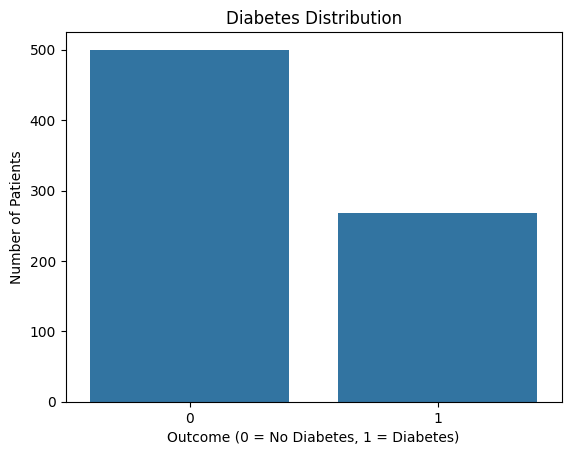

In [196]:
import matplotlib.pyplot as plt
import seaborn as sns

# Diabetes outcome distribution
sns.countplot(x="Outcome", data=data)

plt.title("Diabetes Distribution")
plt.xlabel("Outcome (0 = No Diabetes, 1 = Diabetes)")
plt.ylabel("Number of Patients")
plt.show()

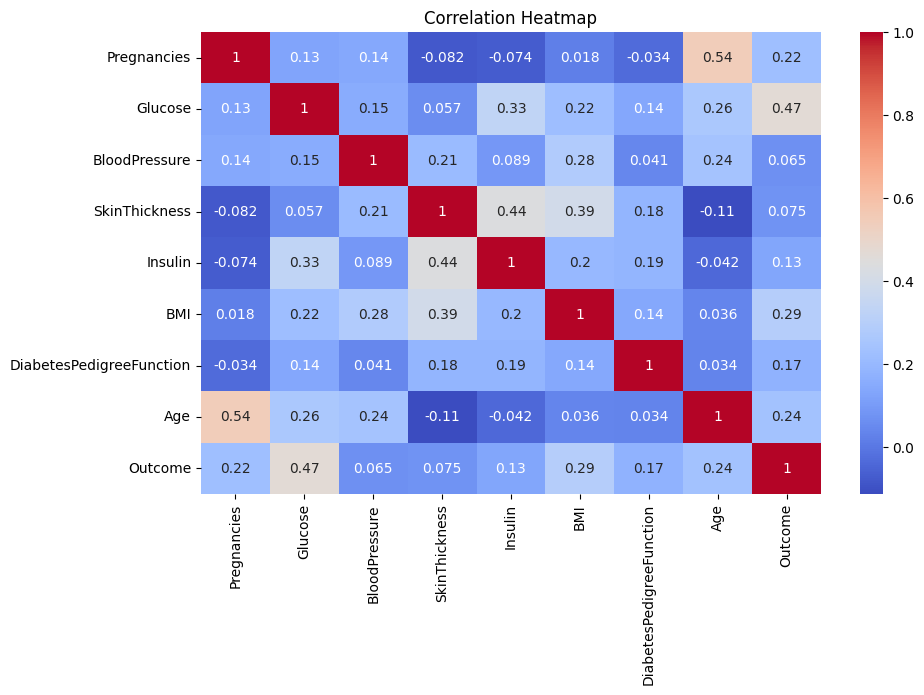

In [197]:
plt.figure(figsize=(10, 6))

sns.heatmap(data.corr(), annot=True, cmap="coolwarm")

plt.title("Correlation Heatmap")
plt.show()

In [198]:
# Input features
X = data.drop("Outcome", axis=1)

# Target variable
y = data["Outcome"]

print("Features:")
print(X.head())

print("\nTarget:")
print(y.head())

Features:
   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6      148             72             35        0  33.6   
1            1       85             66             29        0  26.6   
2            8      183             64              0        0  23.3   
3            1       89             66             23       94  28.1   
4            0      137             40             35      168  43.1   

   DiabetesPedigreeFunction  Age  
0                     0.627   50  
1                     0.351   31  
2                     0.672   32  
3                     0.167   21  
4                     2.288   33  

Target:
0    1
1    0
2    1
3    0
4    1
Name: Outcome, dtype: int64


In [199]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print("ML libraries ready!")

ML libraries ready!


In [200]:
X = data.drop("Outcome", axis=1)
y = data["Outcome"]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (768, 8)
y shape: (768,)


In [201]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (614, 8)
Testing data: (154, 8)


In [202]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print("Feature scaling completed!")


Feature scaling completed!


In [203]:
model = LogisticRegression()

model.fit(X_train, y_train)

print("Model training completed!")

Model training completed!


In [204]:
y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)
print("Accuracy Percentage:", accuracy * 100, "%")

Accuracy: 0.7142857142857143
Accuracy Percentage: 71.42857142857143 %


In [205]:
print("Classification Report:")
print(classification_report(y_test, y_pred))

Classification Report:
              precision    recall  f1-score   support

           0       0.76      0.82      0.79       100
           1       0.61      0.52      0.56        54

    accuracy                           0.71       154
   macro avg       0.68      0.67      0.67       154
weighted avg       0.71      0.71      0.71       154



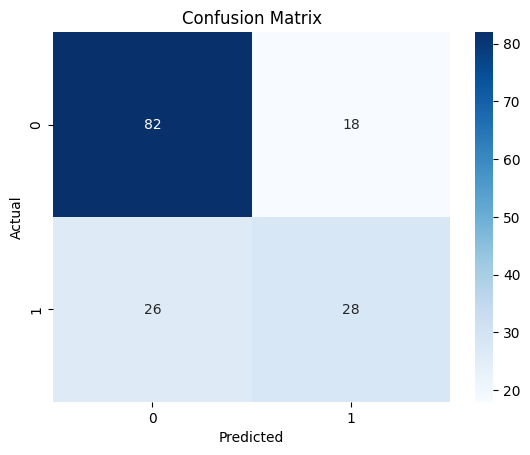

In [206]:
cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [207]:
patient = [[
    2,       # Pregnancies
    120,     # Glucose
    70,      # Blood Pressure
    30,      # Skin Thickness
    100,     # Insulin
    32.0,    # BMI
    0.5,     # Diabetes Pedigree Function
    25       # Age
]]

patient_scaled = scaler.transform(patient)

prediction = model.predict(patient_scaled)

if prediction[0] == 1:
    print("Prediction: Diabetic")
else:
    print("Prediction: Not Diabetic")

Prediction: Not Diabetic


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [208]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.76      0.82      0.79       100
           1       0.61      0.52      0.56        54

    accuracy                           0.71       154
   macro avg       0.68      0.67      0.67       154
weighted avg       0.71      0.71      0.71       154



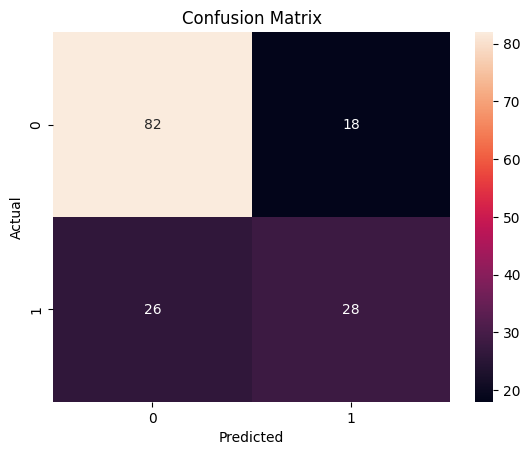

In [209]:

cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt="d")
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [210]:
patient = [[2, 120, 70, 30, 100, 32.0, 0.5, 25]]

patient_scaled = scaler.transform(patient)
prediction = model.predict(patient_scaled)

if prediction[0] == 1:
    print("Prediction: Diabetic")
else:
    print("Prediction: Not Diabetic")

Prediction: Not Diabetic


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [211]:
# Final Result

print("===== DIABETES PREDICTION MODEL =====")
print("Model: Logistic Regression")
print("Accuracy:", round(accuracy * 100, 2), "%")

print("\nSample Patient Prediction:")

if prediction[0] == 1:
    print("Result: Diabetic")
else:
    print("Result: Not Diabetic")

===== DIABETES PREDICTION MODEL =====
Model: Logistic Regression
Accuracy: 71.43 %

Sample Patient Prediction:
Result: Not Diabetic
